# From a synthetic polycrystal to an interactive MD-space motif map

This notebook is a compact, executable demonstration of the paper's full path:

1. generate a perturbed four-phase polycrystal with the generator preserved on
   `paper_version`;
2. extract 128-atom local environments at their physical MD coordinates;
3. train a rotation-aware encoder with VICReg and **no motif labels**;
4. cluster frozen invariant embeddings with K-Means;
5. map the assignments back into the original 3D simulation box.

The large interactive plots below are **physical MD space** (`x`, `y`, `z` in
angstrom), not a three-dimensional PCA projection. Drag to rotate, scroll to
zoom, and hover over a center atom to inspect its coordinates.

The generator and MD renderer are restored from `paper_version`. The notebook
uses a scaled 48 Å / 8-grain configuration so the complete workflow executes in
about a minute on a GPU. The exact 200 Å / 16-grain submission configuration is
retained at `configs/data/data_synth_polycrystalline_balanced_geometries.yaml`.

In [1]:
from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
from IPython.display import HTML, display
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    confusion_matrix,
    normalized_mutual_info_score,
)
import torch
from torch.utils.data import DataLoader, TensorDataset

search_roots = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (
        path
        for path in search_roots
        if (path / "src").is_dir() and (path / "paper" / "main.tex").is_file()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the PointCloudMaterials repository root. "
        f"Notebook working directory: {Path.cwd()}"
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_utils.synthetic import SyntheticAtomisticDatasetGenerator
from src.models import (
    build_encoder,
    encode_point_clouds,
    prepare_encoder_input,
    split_encoder_output,
)
from src.training_methods.contrastive_learning import VICRegLoss
from src.utils.pointcloud_ops import crop_to_num_points
from src.vis_tools.md_cluster_plot import (
    render_interactive_md_clusters,
    save_interactive_md_plot,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Repository root: {REPO_ROOT.name}")
print(f"PyTorch: {torch.__version__}")

Repository root: PointCloudMaterials
PyTorch: 2.11.0+cu128


## 1. Reproducible paper-scale local environments

Each environment contains the paper's 128 nearest atoms inside a 7.4 Å
cutoff. The encoder receives 80-atom neighbor-centered views. The synthetic
labels are used to form a balanced diagnostic split and to report metrics;
the optimizer's DataLoader contains coordinates only.

In [2]:
SEED = 7
RAW_POINTS = 128
VIEW_POINTS = 80
RADIUS = 7.4
TRAIN_PER_PHASE = 200
TEST_PER_PHASE = 60
EPOCHS = 80
BATCH_SIZE = 64

# Choices retained in this branch: vn_atomic, vn_dgcnn, vn_pointnet,
# dgcnn, and pointnet. The last two are rotation-sensitive controls.
ENCODER_VARIANT = "vn_atomic"

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEMO_CONFIG = REPO_ROOT / "configs/data/paper_demo_polycrystal.yaml"
FULL_PAPER_CONFIG = (
    REPO_ROOT
    / "configs/data/data_synth_polycrystalline_balanced_geometries.yaml"
)
GENERATED_DIR = REPO_ROOT / "output/notebook_polycrystal"
ANALYSIS_DIR = REPO_ROOT / "output/notebook_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Encoder: {ENCODER_VARIANT}")
print(f"Notebook config: {DEMO_CONFIG.relative_to(REPO_ROOT)}")
print(f"Full paper config: {FULL_PAPER_CONFIG.relative_to(REPO_ROOT)}")

Device: cuda
Encoder: vn_atomic
Notebook config: configs/data/paper_demo_polycrystal.yaml
Full paper config: configs/data/data_synth_polycrystalline_balanced_geometries.yaml


## 2. Generate the paper polycrystal

This is the submission-era `SyntheticAtomisticDatasetGenerator`, including
Voronoi grains, independently oriented BCC/FCC/HCP lattices, an amorphous
phase, thermal displacement, vacancies, rotation/density bubbles, interface
construction, and minimum-distance relaxation.

The notebook derivative uses the generator's fast liquid path. A warning that
the hard-core liquid did not reach its nominal density is deliberately printed
by the original code; it is not hidden or silently replaced.

In [3]:
generator = SyntheticAtomisticDatasetGenerator(
    DEMO_CONFIG,
    progress=True,
    skip_visualization=True,
)
generator.run()

atoms = np.load(GENERATED_DIR / "atoms_full.npy")
metadata = json.loads((GENERATED_DIR / "metadata.json").read_text())
phase_mapping = json.loads((GENERATED_DIR / "phase_mapping.json").read_text())

atom_coords = atoms["position"].astype(np.float32)
atom_phase_ids = atoms["phase_id"].astype(np.int64)
PHASE_NAMES = tuple(
    phase_mapping["id_to_name"][str(phase_id)]
    for phase_id in range(len(phase_mapping["id_to_name"]))
)
DISPLAY_NAMES = tuple(name.replace("_iron", "").replace("_pure", "").upper()
                      for name in PHASE_NAMES)
NUM_CLASSES = len(PHASE_NAMES)
BOX_SIZE = float(metadata["global"]["box_size"])

print(f"Generated atoms: {len(atoms):,}")
print(f"Box: {BOX_SIZE:.1f} Å × {BOX_SIZE:.1f} Å × {BOX_SIZE:.1f} Å")
print("Phase IDs:", dict(enumerate(DISPLAY_NAMES)))

[    0.00s] ============================================================
[    0.00s] Synthetic Atomistic Dataset Generator v2.0
[    0.00s] ============================================================
[    0.00s] Step 1/6: Building reference structures
[    0.00s] Building reference structures for 4 phases
[    0.00s] Reference structures complete
[    0.00s] Step 2/6: Sampling grains
[    0.00s] Sampling grain seeds and phases
[    0.00s] Sampled 8 grains
[    0.00s] Step 3/6: Populating atoms
[    0.00s] Populating atoms for all grains


[    1.02s]   Grain 0: 1208 atoms
[    1.03s]   Grain 1: 979 atoms
[    1.04s]   Grain 2: 460 atoms
[    1.05s]   Grain 3: 695 atoms
[    1.06s]   Grain 4: 1693 atoms
[    1.06s]   Grain 5: 811 atoms
[    1.07s]   Grain 6: 1254 atoms


[    2.13s]   Grain 7: 1944 atoms
[    2.13s] Classifying atoms to grains
[    2.13s]     Deduplicating overlapping atoms...
[    2.14s] Generating interface atoms
[    2.14s] Total atoms: 9044
[    2.15s]   NN diagnostics (post_population): mean=2.231Å min=0.542Å P1=1.056Å
[    2.15s]   ⚠️ WARNING: NN min < 1.0Å detected! (66 atoms)
[    2.15s] Step 4/6: Applying perturbations
[    2.16s] Applying perturbations:
[    2.16s]   • Rotation bubbles
[    2.17s]     Applied 4 rotation bubbles
[    2.17s]   • Thermal noise
[    2.17s]     Jittered 9044 atoms
[    2.17s]   • Vacancy dropouts


[    2.35s]     Created 73 vacancies
[    2.35s]   • Density bubbles
[    2.36s]     Applied 4 density bubbles
[    2.36s]   • Enforcing minimum distance
[    2.42s]     Resolved 12907 overlapping pairs
[    2.44s]   NN diagnostics (post_perturbation): mean=2.206Å min=2.054Å P1=2.109Å
[    2.44s] Step 5/6: Saving outputs
[    2.44s] Saving outputs to output/notebook_polycrystal
[    2.45s] Saved 8963 atoms
[    2.45s] Step 6/6: Skipping visualizations
[    2.45s] ============================================================
[    2.45s] Generation complete in 2.45s
[    2.45s] ============================================================
Generated atoms: 8,963
Box: 48.0 Å × 48.0 Å × 48.0 Å
Phase IDs: {0: 'AMORPHOUS', 1: 'BCC', 2: 'FCC', 3: 'HCP'}


## 3. Extract neighborhoods and retain their MD coordinates

The KD-tree query returns the center atom first, followed by its 127 nearest
neighbors. Centers closer than one cutoff radius to a box face are excluded,
as in the paper configuration. The unnormalized center coordinates are kept
for the final spatial map; only centered neighborhoods are divided by the
cutoff before entering the network.

In [4]:
atom_tree = cKDTree(atom_coords)
neighbor_distances, neighbor_indices = atom_tree.query(
    atom_coords,
    k=RAW_POINTS,
    workers=-1,
)
complete_neighborhood = neighbor_distances[:, -1] <= RADIUS
away_from_box_faces = np.all(
    (atom_coords >= RADIUS) & (atom_coords <= BOX_SIZE - RADIUS),
    axis=1,
)
eligible_ids = np.flatnonzero(complete_neighborhood & away_from_box_faces)

eligible_counts = np.bincount(
    atom_phase_ids[eligible_ids],
    minlength=NUM_CLASSES,
)
required_per_phase = TRAIN_PER_PHASE + TEST_PER_PHASE
if np.any(eligible_counts < required_per_phase):
    raise RuntimeError(
        "The generated box does not contain enough complete neighborhoods. "
        f"required_per_phase={required_per_phase}, "
        f"available={dict(zip(DISPLAY_NAMES, eligible_counts.tolist()))}"
    )

split_rng = np.random.default_rng(SEED)
train_center_ids = []
test_center_ids = []
for phase_id in range(NUM_CLASSES):
    phase_center_ids = eligible_ids[
        atom_phase_ids[eligible_ids] == phase_id
    ].copy()
    split_rng.shuffle(phase_center_ids)
    train_center_ids.extend(phase_center_ids[:TRAIN_PER_PHASE])
    test_center_ids.extend(
        phase_center_ids[
            TRAIN_PER_PHASE : TRAIN_PER_PHASE + TEST_PER_PHASE
        ]
    )


def neighborhoods_for(center_ids, *, shuffle: bool):
    center_ids = np.asarray(center_ids, dtype=np.int64)
    points = atom_coords[neighbor_indices[center_ids]]
    points = (points - atom_coords[center_ids, None, :]) / RADIUS
    labels = atom_phase_ids[center_ids]
    coords = atom_coords[center_ids]
    if shuffle:
        order = split_rng.permutation(len(center_ids))
        points, labels, coords = points[order], labels[order], coords[order]
    return (
        torch.from_numpy(points.astype(np.float32)),
        torch.from_numpy(labels.astype(np.int64)),
        coords,
    )


train_points, train_labels, _ = neighborhoods_for(
    train_center_ids,
    shuffle=True,
)
test_points, test_labels, test_coords = neighborhoods_for(
    test_center_ids,
    shuffle=True,
)
spatial_points, spatial_labels, spatial_coords = neighborhoods_for(
    eligible_ids,
    shuffle=False,
)

print("Complete interior centers:", len(eligible_ids))
print("Available by phase:", dict(zip(DISPLAY_NAMES, eligible_counts.tolist())))
print(f"Balanced train/test: {len(train_points)}/{len(test_points)}")
print(f"Spatial inference tensor: {tuple(spatial_points.shape)}")

Complete interior centers: 1855
Available by phase: {'AMORPHOUS': 265, 'BCC': 708, 'FCC': 553, 'HCP': 329}
Balanced train/test: 800/240
Spatial inference tensor: (1855, 128, 3)


### Interactive synthetic reference in physical MD space

This first spatial plot colors each eligible center by the generator's phase.
It is a reference available only because the data are synthetic. The
post-training plot later uses K-Means assignments.

In [5]:
# These are the paper-version synthetic visualization's phase-family colors.
PAPER_PHASE_COLORS = {
    0: "#BE5A5A",  # amorphous
    1: "#2F6DB3",  # BCC
    2: "#E3872D",  # FCC
    3: "#4E9C63",  # HCP
}
print("Legend:", {f"Phase {i}": name for i, name in enumerate(DISPLAY_NAMES)})

reference_html = ANALYSIS_DIR / "md_space_reference_phases.html"
save_interactive_md_plot(
    spatial_coords,
    spatial_labels.numpy(),
    reference_html,
    cluster_color_map=PAPER_PHASE_COLORS,
    marker_size=3.0,
    title="Synthetic reference phases in physical MD coordinates (Å)",
    label_prefix="Phase",
    aspect_mode="data",
)
display(HTML(reference_html.read_text(encoding="utf-8")))

Legend: {'Phase 0': 'AMORPHOUS', 'Phase 1': 'BCC', 'Phase 2': 'FCC', 'Phase 3': 'HCP'}


## 4. Rotation-aware encoder and VICReg views

The default is the maintained atomic VN-RevNet. Every retained architecture
uses the same view construction and objective. `VICRegLoss` creates a centered
and a neighbor-centered 80-atom view, with small strain, jitter, and dropout.

In [6]:
ENCODER_SPECS = {
    "vn_atomic": (
        "VN_REVNET_Atomic",
        dict(
            latent_size=32,
            k_embed=10,
            k_list=(8, 12),
            embed_channels=16,
            hidden_channels=(32, 48),
            geom_k=10,
            geom_dim=16,
            global_pooling="mean",
            use_batchnorm=True,
        ),
    ),
    "vn_dgcnn": (
        "VN_DGCNN",
        dict(
            latent_size=48,
            n_knn=10,
            feature_dims=(24, 24, 48, 72, 96),
            global_mlp_dims=(96, 64),
            global_dropout=0.0,
            use_batchnorm=True,
            use_cross_product=True,
        ),
    ),
    "vn_pointnet": (
        "PnE_VN",
        dict(
            latent_size=48,
            n_knn=10,
            feature_transform=False,
            hidden_dim1=48,
            hidden_dim2=96,
            use_batchnorm=True,
        ),
    ),
    "dgcnn": (
        "DGCNN",
        dict(
            latent_size=48,
            n_knn=10,
            feature_dims=(24, 24, 48, 72),
            emb_dims=96,
            dropout_rate=0.0,
            use_batchnorm=True,
        ),
    ),
    "pointnet": (
        "PnE_S",
        dict(latent_size=48, feature_transform=False, dropout_rate=0.0),
    ),
}

if ENCODER_VARIANT not in ENCODER_SPECS:
    raise ValueError(
        f"Unknown ENCODER_VARIANT={ENCODER_VARIANT!r}; "
        f"choose one of {sorted(ENCODER_SPECS)}."
    )
encoder_name, encoder_kwargs = ENCODER_SPECS[ENCODER_VARIANT]
encoder = build_encoder(encoder_name, **encoder_kwargs).to(DEVICE)


def prepare_for_encoder(points: torch.Tensor) -> torch.Tensor:
    return prepare_encoder_input(encoder, points)


def select_invariant_output(raw_output):
    output = split_encoder_output(encoder, raw_output)
    return output.invariant, None


vicreg = VICRegLoss(
    enabled=True,
    weight=1.0,
    sim_coeff=25.0,
    std_coeff=25.0,
    cov_coeff=1.0,
    embed_dim=64,
    start_epoch=0,
    jitter_std=0.008,
    jitter_mode="absolute",
    jitter_scale=1.0,
    drop_ratio=0.01,
    view_points=VIEW_POINTS,
    neighbor_view=True,
    neighbor_view_mode="second",
    neighbor_k=6,
    neighbor_max_relative_distance=0.0,
    drop_apply_to_both=True,
    rotation_mode="none",
    rotation_deg=0.0,
    mirror_prob=0.0,
    strain_std=0.01,
    strain_volume_preserve=True,
    occlusion_mode="none",
    occlusion_view="second",
    occlusion_slab_frac=0.2,
    occlusion_cone_deg=20.0,
    occlusion_prob=1.0,
    std_eps=1e-4,
    std_target=1.0,
    input_dim=encoder.invariant_dim,
).to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in list(encoder.parameters()) + list(vicreg.parameters())
    if parameter.requires_grad
)
print(f"Registry name: {encoder_name}")
print(f"Trainable parameters: {parameter_count:,}")
print(f"Invariant embedding dimension: {encoder.invariant_dim}")

Registry name: VN_REVNET_Atomic
Trainable parameters: 23,521
Invariant embedding dimension: 48


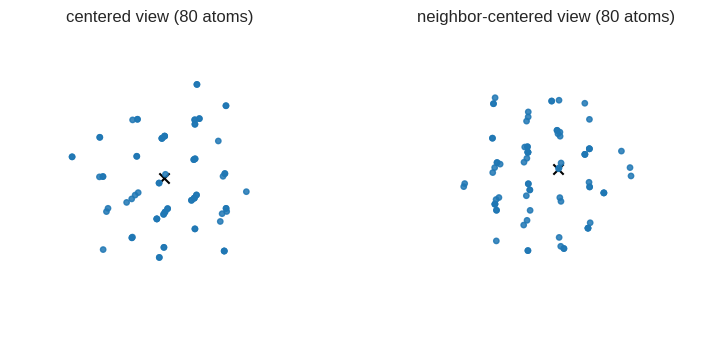

In [7]:
example = train_points[:1].to(DEVICE)
with torch.no_grad():
    centered_view = vicreg._augment(
        example,
        use_neighbor=False,
        apply_occlusion=False,
    )
    neighbor_view = vicreg._augment(
        example,
        use_neighbor=True,
        apply_occlusion=False,
    )

fig = plt.figure(figsize=(8, 3.5))
for panel, (title, view) in enumerate(
    (("centered view", centered_view), ("neighbor-centered view", neighbor_view)),
    start=1,
):
    points = view[0].cpu().numpy()
    axis = fig.add_subplot(1, 2, panel, projection="3d")
    axis.scatter(points[:, 0], points[:, 1], points[:, 2], s=15, alpha=0.85)
    axis.scatter(0, 0, 0, s=55, c="black", marker="x")
    axis.set_title(f"{title} ({len(points)} atoms)")
    axis.set_axis_off()
    axis.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

## 5. Evaluation helpers

Cluster identifiers are arbitrary, so accuracy uses Hungarian matching.
NMI and ARI are permutation-invariant. The SO(3) diagnostic independently
rotates every held-out neighborhood before encoding it again.

In [8]:
@torch.no_grad()
def extract_embeddings(
    points: torch.Tensor,
    *,
    apply_fresh_rotation: bool = False,
) -> np.ndarray:
    encoder.eval()
    embeddings = []
    loader = DataLoader(TensorDataset(points), batch_size=128, shuffle=False)
    for (batch,) in loader:
        batch = crop_to_num_points(batch.to(DEVICE), VIEW_POINTS)
        if apply_fresh_rotation:
            rotations = vicreg._random_rotation_matrices(
                len(batch),
                device=DEVICE,
                dtype=batch.dtype,
            )
            batch = torch.bmm(batch, rotations.transpose(1, 2))
        output = encode_point_clouds(encoder, batch)
        embeddings.append(output.invariant.float().cpu())
    return torch.cat(embeddings).numpy()


def evaluate_clustering(points: torch.Tensor, labels: torch.Tensor):
    embeddings = extract_embeddings(points)
    kmeans = KMeans(
        n_clusters=NUM_CLASSES,
        init="k-means++",
        n_init=20,
        random_state=SEED,
    ).fit(embeddings)
    predictions = kmeans.labels_
    labels_numpy = labels.numpy()

    contingency = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    for true_class, cluster_id in zip(labels_numpy, predictions):
        contingency[true_class, cluster_id] += 1
    true_ids, cluster_ids = linear_sum_assignment(-contingency)
    cluster_to_class = {
        int(cluster_id): int(true_id)
        for true_id, cluster_id in zip(true_ids, cluster_ids)
    }
    aligned_predictions = np.array(
        [cluster_to_class[int(cluster_id)] for cluster_id in predictions]
    )

    rotated_embeddings = extract_embeddings(
        points,
        apply_fresh_rotation=True,
    )
    relative_rotation_error = np.linalg.norm(
        embeddings - rotated_embeddings,
        axis=1,
    ) / (np.linalg.norm(embeddings, axis=1) + 1e-9)

    return {
        "embeddings": embeddings,
        "kmeans": kmeans,
        "raw_predictions": predictions,
        "aligned_predictions": aligned_predictions,
        "cluster_to_class": cluster_to_class,
        "accuracy": float(np.mean(aligned_predictions == labels_numpy)),
        "nmi": float(normalized_mutual_info_score(labels_numpy, predictions)),
        "ari": float(adjusted_rand_score(labels_numpy, predictions)),
        "rotation_error_mean": float(relative_rotation_error.mean()),
        "rotation_error_max": float(relative_rotation_error.max()),
    }


def print_metrics(title: str, result: dict) -> None:
    print(title)
    print(f"  Hungarian-matched ACC: {result['accuracy']:.3f}")
    print(f"  NMI:                   {result['nmi']:.3f}")
    print(f"  ARI:                   {result['ari']:.3f}")
    print(
        "  rotation error:        "
        f"mean={result['rotation_error_mean']:.2e}, "
        f"max={result['rotation_error_max']:.2e}"
    )

In [9]:
initial_result = evaluate_clustering(test_points, test_labels)
print_metrics("Before self-supervised training", initial_result)

Before self-supervised training
  Hungarian-matched ACC: 0.454
  NMI:                   0.140
  ARI:                   0.103
  rotation error:        mean=3.79e-07, max=6.40e-07


## 6. Self-supervised VICReg training

The DataLoader below contains only `train_points`. It does not contain
`train_labels`; the labels do not participate in the loss or optimizer.

In [10]:
unlabeled_train_loader = DataLoader(
    TensorDataset(train_points),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=torch.Generator().manual_seed(SEED),
)
optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(vicreg.parameters()),
    lr=3e-3,
    weight_decay=1e-5,
)

loss_history = []
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    encoder.train()
    vicreg.train()
    epoch_loss = 0.0
    for (point_batch,) in unlabeled_train_loader:
        point_batch = point_batch.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss, _ = vicreg.compute_loss(
            pc=point_batch,
            encoder=encoder,
            prepare_input=prepare_for_encoder,
            split_output=select_invariant_output,
            current_epoch=epoch,
        )
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite or missing VICReg loss at epoch {epoch + 1}: {loss}"
            )
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    mean_epoch_loss = epoch_loss / len(unlabeled_train_loader)
    loss_history.append(mean_epoch_loss)
    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:02d}/{EPOCHS}: loss={mean_epoch_loss:.4f}")

elapsed = time.perf_counter() - start_time
print(f"Training time: {elapsed:.1f} s on {DEVICE}")

epoch 01/80: loss=22.0316


epoch 10/80: loss=17.9120


epoch 20/80: loss=17.6158


epoch 30/80: loss=16.9104


epoch 40/80: loss=16.2904


epoch 50/80: loss=15.9309


epoch 60/80: loss=15.8619


epoch 70/80: loss=15.6437


epoch 80/80: loss=15.5696
Training time: 41.9 s on cuda


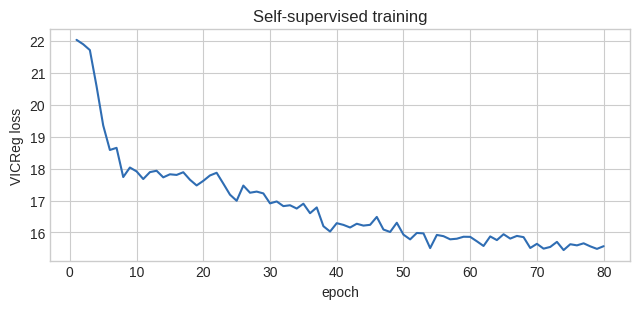

In [11]:
plt.figure(figsize=(6.5, 3.2))
plt.plot(np.arange(1, EPOCHS + 1), loss_history, color="#2F6DB3")
plt.xlabel("epoch")
plt.ylabel("VICReg loss")
plt.title("Self-supervised training")
plt.tight_layout()
plt.show()

## 7. Freeze and cluster

Labels enter only now to match arbitrary K-Means IDs and report metrics.

In [12]:
final_result = evaluate_clustering(test_points, test_labels)
print_metrics("After self-supervised training", final_result)

After self-supervised training
  Hungarian-matched ACC: 0.750
  NMI:                   0.528
  ARI:                   0.452
  rotation error:        mean=3.64e-07, max=8.06e-07


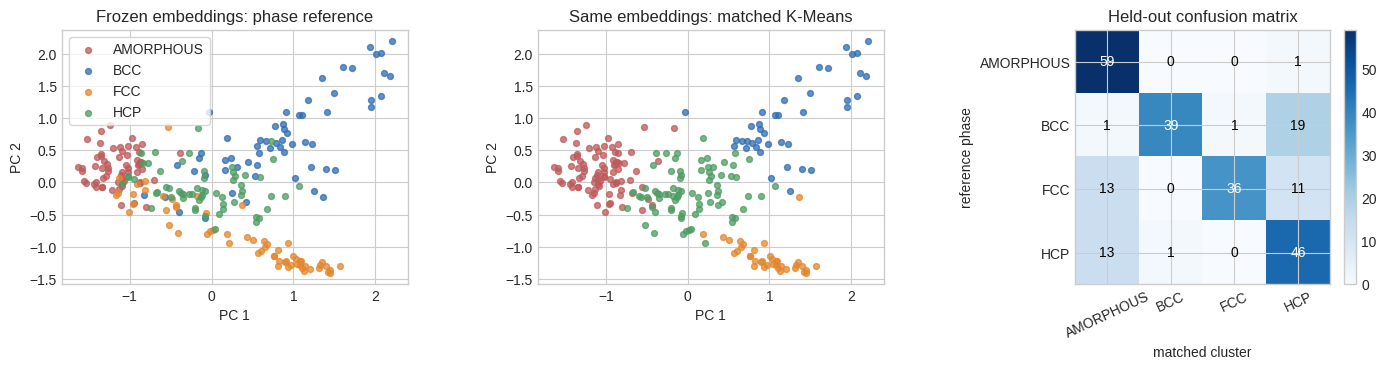

In [13]:
embedding_2d = PCA(n_components=2, random_state=SEED).fit_transform(
    final_result["embeddings"]
)
true_labels = test_labels.numpy()
predicted_labels = final_result["aligned_predictions"]
matrix = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for class_id, name in enumerate(DISPLAY_NAMES):
    true_mask = true_labels == class_id
    axes[0].scatter(
        embedding_2d[true_mask, 0],
        embedding_2d[true_mask, 1],
        s=18,
        alpha=0.75,
        label=name,
        color=PAPER_PHASE_COLORS[class_id],
    )
    cluster_mask = predicted_labels == class_id
    axes[1].scatter(
        embedding_2d[cluster_mask, 0],
        embedding_2d[cluster_mask, 1],
        s=18,
        alpha=0.75,
        color=PAPER_PHASE_COLORS[class_id],
    )
axes[0].set_title("Frozen embeddings: phase reference")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend(frameon=True)
axes[1].set_title("Same embeddings: matched K-Means")
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")

image = axes[2].imshow(matrix, cmap="Blues")
for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        axes[2].text(
            column,
            row,
            str(matrix[row, column]),
            ha="center",
            va="center",
            color="white" if matrix[row, column] > matrix.max() / 2 else "black",
        )
axes[2].set_xticks(np.arange(NUM_CLASSES), DISPLAY_NAMES, rotation=25)
axes[2].set_yticks(np.arange(NUM_CLASSES), DISPLAY_NAMES)
axes[2].set_xlabel("matched cluster")
axes[2].set_ylabel("reference phase")
axes[2].set_title("Held-out confusion matrix")
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8. Post-training clusters in physical MD space

Every complete center in the box is now embedded and assigned by the K-Means
model fitted above. The exact post-training analysis file convention is used:
`local_structure_coords_clusters.npz` stores physical coordinates and raw
cluster IDs, and the `paper_version` renderer turns it into an interactive
`md_space_clusters.html`.

These cluster IDs are deliberately left raw in the plot. Their numbers and
colors are arbitrary; spatial coherence and boundaries are the meaningful
result.

In [14]:
spatial_embeddings = extract_embeddings(spatial_points)
spatial_cluster_ids = final_result["kmeans"].predict(spatial_embeddings)
np.savez(
    ANALYSIS_DIR / "local_structure_coords_clusters.npz",
    coords=spatial_coords.astype(np.float32),
    clusters=spatial_cluster_ids.astype(np.int64),
)

md_cluster_html = render_interactive_md_clusters(
    ANALYSIS_DIR,
    out_file=ANALYSIS_DIR / "md_space_clusters.html",
    palette="tab10",
    marker_size=3.0,
    marker_line_width=0.0,
    aspect_mode="data",
)
print(
    "Saved analysis data: "
    f"{(ANALYSIS_DIR / 'local_structure_coords_clusters.npz').relative_to(REPO_ROOT)}"
)
print(f"Saved interactive plot: {md_cluster_html.relative_to(REPO_ROOT)}")
display(HTML(md_cluster_html.read_text(encoding="utf-8")))

Saved analysis data: output/notebook_analysis/local_structure_coords_clusters.npz
Saved interactive plot: output/notebook_analysis/md_space_clusters.html


In [15]:
spatial_true = spatial_labels.numpy()
spatial_aligned = np.array(
    [
        final_result["cluster_to_class"][int(cluster_id)]
        for cluster_id in spatial_cluster_ids
    ]
)
print(
    "Whole interior spatial map (synthetic diagnostic only):\n"
    f"  matched ACC={np.mean(spatial_aligned == spatial_true):.3f}\n"
    f"  NMI={normalized_mutual_info_score(spatial_true, spatial_cluster_ids):.3f}\n"
    f"  ARI={adjusted_rand_score(spatial_true, spatial_cluster_ids):.3f}"
)

Whole interior spatial map (synthetic diagnostic only):
  matched ACC=0.685
  NMI=0.471
  ARI=0.359


## What this demonstrates

- Data come from the paper-version polycrystal generator, including all four
  benchmark phases and submission perturbations.
- The self-supervised optimizer receives only coordinates.
- Neighbor-centered 80-atom views reuse the maintained VICReg path.
- The VN embedding is checked after fresh global SO(3) rotations.
- K-Means assignments are returned to the original physical MD coordinates
  with the paper-version post-training renderer.

This remains a qualitative integration demonstration, not a reproduction of
the paper's tables. Use the full retained configuration and multiple seeds for
paper-scale experiments.